# Lab 10 — Data Analysis & Aggregation
AI Detection Papers Analytics Pipeline

## Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt

CLEANED_CSV = '../data/processed/cleaned/cleaned_data.csv'
df = pd.read_csv(CLEANED_CSV)
print(f'Loaded {len(df)} rows × {len(df.columns)} columns')
df.head()

Loaded 50 rows × 12 columns


,paper_id,title,authors,abstract,published_date,primary_category,all_categories,pdf_url,citation_count,relevance_score,language,published_year
0,2605.00924,Styleshield: Exposing The Fragility Of Aigc De...,Guantian Zheng,AI-generated content (AIGC) detectors are incr...,2026-04-30,cs.LG,cs.LG|cs.AI,https://arxiv.org/pdf/2605.00924,81,0.5557,en,2026
1,2604.26990,Ucsc-Nlp At Semeval-2026 Task 13: Multi-View G...,Kargi Chauhan; Sadiba Nusrat Nur,With the rapid growth of large language models...,2026-04-28,cs.SE,cs.SE,https://arxiv.org/pdf/2604.26990,94,0.6375,en,2026
2,2604.25370,Gpt-Image-2 In The Wild: A Twitter Dataset Of ...,Kidus Zewde; Simiao Ren; Xingyu Shen; Jenny Wu...,The release of GPT-image-2 by OpenAI marks a w...,2026-04-28,cs.CV,cs.CV|cs.AI,https://arxiv.org/pdf/2604.25370,28,0.5698,en,2026
3,2604.24426,Dymapia: A Multi-Domain Framework For Detectin...,Md Shohel Rana; Andrew H. Sung,"AI-generated media are advancing rapidly, rais...",2026-04-27,cs.CV,cs.CV,https://arxiv.org/pdf/2604.24426,13,0.8383,en,2026
4,2604.24004,Single-Cycle Multidirectional Eog Classificati...,Tasnia Nabiha; Orthy Toor; Wakim Sajjad Sakib;...,Electrooculogram (EOG) is a non-invasive bio-s...,2026-04-27,eess.SP,eess.SP,https://arxiv.org/pdf/2604.24004,114,0.7727,en,2026


## Part 1 — MySQL: Populate and Query paper_metrics

In [10]:
from src.analytics.db_connector import run_db_pipeline

try:
    db_df = run_db_pipeline(df)
    print(f'MySQL round-trip OK: {len(db_df)} rows')
    display(db_df.head())
except Exception as e:
    print(f'MySQL unavailable: {e}')
    print('Using cleaned CSV as fallback for DB data')
    db_df = df[['paper_id','title','citation_count','relevance_score',
                'published_year','primary_category']].copy()
    db_df['paper_id'] = db_df['paper_id'].astype(str)

2026-05-06 11:15:28,039 - INFO - [DBConnector] MySQL connection established
2026-05-06 11:15:28,109 - INFO - [DBConnector] Table paper_metrics ready
2026-05-06 11:15:28,159 - INFO - [DBConnector] Inserted 50 rows into paper_metrics
/home/fadil/AiDetectionAnalytics/src/analytics/db_connector.py:96: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)
2026-05-06 11:15:28,350 - INFO - [DBConnector] Queried 50 rows from paper_metrics
2026-05-06 11:15:28,351 - INFO - [DBConnector] Connection closed


MySQL round-trip OK: 50 rows


,paper_id,title,citation_count,relevance_score,published_year,primary_category
0,2603.07401,Vivecaption: A Split Approach To Caption Quali...,83,0.7496,2026,cs.CV
1,2603.07666,Ai-Driven Phase Identification From X-Ray Hype...,91,0.6573,2026,cond-mat.mtrl-sci
2,2603.10598,Layer Consistency Matters: Elegant Latent Tran...,120,0.7836,2026,cs.CV
3,2603.15037,Phonemedf: A Synthetic Speech Dataset For Audi...,40,0.7006,2026,cs.SD
4,2603.18625,Genvideolens: Where Lvlms Fall Short In Ai-Gen...,105,0.5161,2026,cs.CV


## Part 2 — Combining Data Sources (4 join types)

In [3]:
from src.analytics.data_combiner import compare_join_types, combine_sources, save_join_comparison_chart
from pathlib import Path

csv_df = df.copy()
csv_df['paper_id'] = csv_df['paper_id'].astype(str)

counts = compare_join_types(csv_df, db_df)
print('Row counts per join type:')
for how, n in counts.items():
    print(f'  {how:6s}: {n} rows')

save_join_comparison_chart(counts, Path('../data/processed/analytics'))
print('\nBest join: INNER — only papers present in both sources')

combined_df = combine_sources(csv_df, db_df)
print(f'Combined DataFrame: {combined_df.shape}')

2026-05-06 11:12:15,070 - INFO - [DataCombiner] INNER join → 50 rows
2026-05-06 11:12:15,079 - INFO - [DataCombiner] LEFT join → 50 rows
2026-05-06 11:12:15,087 - INFO - [DataCombiner] RIGHT join → 50 rows
2026-05-06 11:12:15,098 - INFO - [DataCombiner] OUTER join → 50 rows
2026-05-06 11:12:15,296 - INFO - [DataCombiner] Join comparison chart saved to ../data/processed/analytics/join_comparison.png
2026-05-06 11:12:15,302 - INFO - [DataCombiner] INNER join → 50 rows


Row counts per join type:
  inner : 50 rows
  left  : 50 rows
  right : 50 rows
  outer : 50 rows

Best join: INNER — only papers present in both sources


2026-05-06 11:12:15,311 - INFO - [DataCombiner] Combined DataFrame: 50 rows × 12 cols


Combined DataFrame: (50, 12)


## Part 3 — Reshaping: melt() and pivot_table()

In [4]:
from src.analytics.pivot_builder import (
    extract_primary_category, wide_to_long, long_to_wide,
    build_pivot_table, build_crosstab, save_pivot_csv
)
from pathlib import Path

df = extract_primary_category(df)

# Wide → Long (melt 3 numeric columns)
long_df = wide_to_long(df)
print('Long format:')
display(long_df.head(9))

# Long → Wide (pivot back)
wide_df = long_to_wide(long_df)
print('Back to wide:')
display(wide_df.head())

# Pivot table: avg citations by year × category
pivot = build_pivot_table(df)
print('Pivot table (avg citations by year × category):')
display(pivot)
save_pivot_csv(pivot, out_dir=Path('../data/processed/analytics'))

# Crosstab: language × year
ct = build_crosstab(df)
print('Crosstab (language × year):')
display(ct)

2026-05-06 11:12:20,262 - INFO - [PivotBuilder] wide→long: 150 rows × 5 cols


Long format:


,paper_id,title,primary_category,metric,value
0,2605.00924,Styleshield: Exposing The Fragility Of Aigc De...,cs.LG,citation_count,81.0
1,2604.26990,Ucsc-Nlp At Semeval-2026 Task 13: Multi-View G...,cs.SE,citation_count,94.0
2,2604.25370,Gpt-Image-2 In The Wild: A Twitter Dataset Of ...,cs.CV,citation_count,28.0
3,2604.24426,Dymapia: A Multi-Domain Framework For Detectin...,cs.CV,citation_count,13.0
4,2604.24004,Single-Cycle Multidirectional Eog Classificati...,eess.SP,citation_count,114.0
5,2605.00874,Latent Space Probing For Adult Content Detecti...,cs.CV,citation_count,75.0
6,2604.23016,"Deepsignature: Digitally Signed, Content-Encod...",cs.CR,citation_count,3.0
7,2604.22089,Ethics Testing: Proactive Identification Of Ge...,cs.SE,citation_count,29.0
8,2604.21300,Explainable Disentangled Representation Learni...,cs.CL,citation_count,3.0


2026-05-06 11:12:20,284 - INFO - [PivotBuilder] long→wide: 50 rows × 4 cols


Back to wide:


...

Pivot table (avg citations by year × category):


primary_category,cond-mat.mtrl-sci,cs.AI,cs.CL,cs.CR,cs.CV,cs.CY,cs.DL,cs.LG,cs.SD,cs.SE,cs.SI,econ.GN,eess.SP,stat.AP,All
published_year,,,,,,,,,,,,,,,
2026,91.0,101.333333,38.0,56.666667,72.15,89.0,8.0,81.0,35.5,66.5,21.0,57.0,114.0,35.0,63.72
All,91.0,101.333333,38.0,56.666667,72.15,89.0,8.0,81.0,35.5,66.5,21.0,57.0,114.0,35.0,63.72


2026-05-06 11:12:20,368 - INFO - [PivotBuilder] Saved pivot table to ../data/processed/analytics/pivot_category_year.csv
2026-05-06 11:12:20,383 - INFO - [PivotBuilder] Crosstab: 1 rows × 1 cols


Crosstab (language × year):


published_year,2026
language,
en,50


## Part 4 — GroupBy Analysis

In [5]:
from src.analytics.aggregator import (
    category_summary, yearly_trends, top_n_per_group,
    save_category_csv, save_yearly_csv, save_yearly_chart
)
from pathlib import Path

ADIR = Path('../data/processed/analytics')

# Category summary (4 agg functions)
summary = category_summary(df)
print('Category summary:')
display(summary)
save_category_csv(summary, ADIR)

# Yearly trends (1990–2027)
trends = yearly_trends(df, start_year=2020, end_year=2027)
print('Yearly trends:')
display(trends)
save_yearly_csv(trends, ADIR)
save_yearly_chart(trends, ADIR)

# Top 3 papers per category
top3 = top_n_per_group(df, n=3)
print('Top 3 papers per category by citations:')
display(top3[['primary_category','title','citation_count']])

2026-05-06 11:12:39,119 - INFO - [Aggregator] Category summary: 14 categories


Category summary:


,primary_category,mean_citations,total_citations,paper_count,median_citations,mean_relevance
4,cs.CV,72.150000,1443,20,81.5,0.720410
3,cs.CR,56.666667,340,6,68.5,0.656467
1,cs.AI,101.333333,304,3,103.0,0.813467
2,cs.CL,38.000000,266,7,35.0,0.727400
9,cs.SE,66.500000,266,4,61.5,0.771075
12,eess.SP,114.000000,114,1,114.0,0.772700
0,cond-mat.mtrl-sci,91.000000,91,1,91.0,0.657300
5,cs.CY,89.000000,89,1,89.0,0.711300
7,cs.LG,81.000000,81,1,81.0,0.555700
8,cs.SD,35.500000,71,2,35.5,0.641150


2026-05-06 11:12:39,138 - INFO - [Aggregator] Saved category_analysis.csv
2026-05-06 11:12:39,238 - INFO - [Aggregator] Yearly trends: 1 years


Yearly trends:


,published_year,paper_count,total_citations,mean_relevance
0,2026,50,3186,0.716734


2026-05-06 11:12:39,252 - INFO - [Aggregator] Saved yearly_trends.csv
2026-05-06 11:12:39,556 - INFO - [Aggregator] Saved yearly_trends.png
2026-05-06 11:12:39,565 - INFO - [Aggregator] Top 3 per 'primary_category': 25 rows


Top 3 papers per category by citations:


,primary_category,title,citation_count
0,cond-mat.mtrl-sci,Ai-Driven Phase Identification From X-Ray Hype...,91
1,cs.AI,Steering The Verifiability Of Multimodal Ai Ha...,110
2,cs.AI,Alignment Imprint: Zero-Shot Ai-Generated Text...,103
3,cs.AI,Reasoning-Aware Aigc Detection Via Alignment A...,91
4,cs.CL,Tab-Audit: Detecting Ai-Fabricated Scientific ...,99
5,cs.CL,Many Ways To Be Fake: Benchmarking Fake News D...,70
6,cs.CL,C-Red: A Comprehensive Chinese Benchmark For A...,45
7,cs.CR,Bioshield: A Context-Aware Firewall For Securi...,118
8,cs.CR,Securebreak -- A Dataset Towards Safe And Secu...,71
9,cs.CR,Dual-Guard: Dual-Channel Latent Watermarking F...,69


## Part 5 — Time Series Analysis

In [6]:
from src.analytics.time_series import (
    parse_dates, extract_date_components,
    monthly_citation_series, resample_yearly,
    rolling_averages, save_rolling_chart
)
from pathlib import Path

df_ts = parse_dates(df)
df_ts = extract_date_components(df_ts)

valid   = df_ts['published_date'].notna().sum()
missing = df_ts['published_date'].isna().sum()
print(f'Valid dates: {valid} | Missing: {missing}')
print('Date components added:', ['ts_year','ts_month','ts_weekday','ts_quarter'])
display(df_ts[['title','published_date','ts_year','ts_month','ts_weekday','ts_quarter']].head())

monthly = monthly_citation_series(df_ts)
print(f'Monthly series: {len(monthly)} months')
display(monthly)

yearly = resample_yearly(monthly)
print('Yearly totals:')
display(yearly)

ra = rolling_averages(monthly)
print('Rolling averages (3/6/12-month):')
display(ra)

save_rolling_chart(ra, Path('../data/processed/analytics'))
print('Chart saved.')

2026-05-06 11:12:49,994 - INFO - [TimeSeries] Parsed 'published_date': 50 valid, 0 missing
2026-05-06 11:12:50,001 - INFO - [TimeSeries] Extracted date components


Valid dates: 50 | Missing: 0
Date components added: ['ts_year', 'ts_month', 'ts_weekday', 'ts_quarter']


,title,published_date,ts_year,ts_month,ts_weekday,ts_quarter
0,Styleshield: Exposing The Fragility Of Aigc De...,2026-04-30,2026,4,Thursday,2
1,Ucsc-Nlp At Semeval-2026 Task 13: Multi-View G...,2026-04-28,2026,4,Tuesday,2
2,Gpt-Image-2 In The Wild: A Twitter Dataset Of ...,2026-04-28,2026,4,Tuesday,2
3,Dymapia: A Multi-Domain Framework For Detectin...,2026-04-27,2026,4,Monday,2
4,Single-Cycle Multidirectional Eog Classificati...,2026-04-27,2026,4,Monday,2


2026-05-06 11:12:50,020 - INFO - [TimeSeries] Parsed 'published_date': 50 valid, 0 missing
2026-05-06 11:12:50,035 - INFO - [TimeSeries] Monthly series: 2 months


Monthly series: 2 months


...

2026-05-06 11:12:50,054 - INFO - [TimeSeries] Rolling averages computed


Rolling averages (3/6/12-month):


,monthly,rolling_3,rolling_6,rolling_12
published_date,,,,
2026-03-31,1242,1242.0,1242.0,1242.0
2026-04-30,1944,1593.0,1593.0,1593.0


2026-05-06 11:12:50,318 - INFO - [TimeSeries] Saved rolling_citations.png


Chart saved.


## Part 6 — MongoDB Aggregation Pipeline

In [7]:
from src.analytics.mongo_pipeline import build_aggregation_pipeline, run_mongo_pipeline

# Show the 4-stage pipeline definition
import json
pipeline = build_aggregation_pipeline(min_relevance=0.5)
print('Aggregation pipeline (4 stages):')
print(json.dumps(pipeline, indent=2))

# Run (uses pandas fallback if MongoDB is offline)
mongo_df = run_mongo_pipeline(min_relevance=0.5, df_fallback=df)
print(f'\nPipeline result ({len(mongo_df)} categories):')
display(mongo_df)

Aggregation pipeline (4 stages):
[
  {
    "$match": {
      "relevance_score": {
        "$gte": 0.5
      }
    }
  },
  {
    "$group": {
      "_id": "$primary_category",
      "avg_citations": {
        "$avg": "$citation_count"
      },
      "total_papers": {
        "$sum": 1
      },
      "max_citations": {
        "$max": "$citation_count"
      }
    }
  },
  {
    "$sort": {
      "avg_citations": -1
    }
  },
  {
    "$project": {
      "_id": 0,
      "category": "$_id",
      "avg_citations": {
        "$round": [
          "$avg_citations",
          2
        ]
      },
      "total_papers": 1,
      "max_citations": 1
    }
  }
]


2026-05-06 11:13:25,138 - WARNING - [MongoPipeline] MongoDB unavailable (localhost:27017: [Errno 111] Connection refused (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms), Timeout: 30s, Topology Description: <TopologyDescription id: 69fb0617a0ee5e653d30c6a9, topology_type: Unknown, servers: [<ServerDescription ('localhost', 27017) server_type: Unknown, rtt: None, error=AutoReconnect('localhost:27017: [Errno 111] Connection refused (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms)')>]>) — using CSV fallback
2026-05-06 11:13:25,152 - INFO - [MongoPipeline] Fallback pipeline: 14 categories



Pipeline result (14 categories):


,category,avg_citations,total_papers,max_citations
0,eess.SP,114.00,1,114
1,cs.AI,101.33,3,110
2,cond-mat.mtrl-sci,91.00,1,91
3,cs.CY,89.00,1,89
4,cs.LG,81.00,1,81
5,cs.CV,72.15,20,120
6,cs.SE,66.50,4,119
7,econ.GN,57.00,1,57
8,cs.CR,56.67,6,118
9,cs.CL,38.00,7,99


## Part 7 — Insight Reporter (4 Analytical Questions)

2026-05-06 11:13:25,188 - INFO - [Insights] Q1: Top category='eess.SP' avg_citations=114.0
2026-05-06 11:13:25,208 - INFO - [Insights] Q2: Highest ROI category='eess.SP' roi=147.53
2026-05-06 11:13:25,221 - INFO - [Insights] Q3: Year range 2026–2026, 1 data points
2026-05-06 11:13:25,232 - INFO - [Insights] Q4: 1 languages; dominant='en' (100.0%)
2026-05-06 11:13:25,467 - INFO - [Insights] Saved category_roi.png
2026-05-06 11:13:25,477 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-06 11:13:25,479 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-06 11:13:25,555 - INFO - [Insights] Saved yearly_volume.png



ANALYTICAL FINDINGS — AI Detection Papers

Q1 — Top categories by avg citations:
 primary_category  avg_citations  paper_count
          eess.SP     114.000000            1
            cs.AI     101.333333            3
cond-mat.mtrl-sci      91.000000            1
            cs.CY      89.000000            1
            cs.LG      81.000000            1
            cs.CV      72.150000           20
            cs.SE      66.500000            4
          econ.GN      57.000000            1
            cs.CR      56.666667            6
            cs.CL      38.000000            7

Q2 — Categories with highest citation ROI:
 primary_category    avg_roi
          eess.SP 147.534619
            cs.LG 145.762102
cond-mat.mtrl-sci 138.445154
            cs.AI 127.362268
            cs.CY 125.123014
            cs.CV 106.459339
            cs.SE  88.875447
            cs.CR  83.313903
          econ.GN  71.734206
            cs.CL  60.872772

Q3 — Papers published per year:
 published_year 

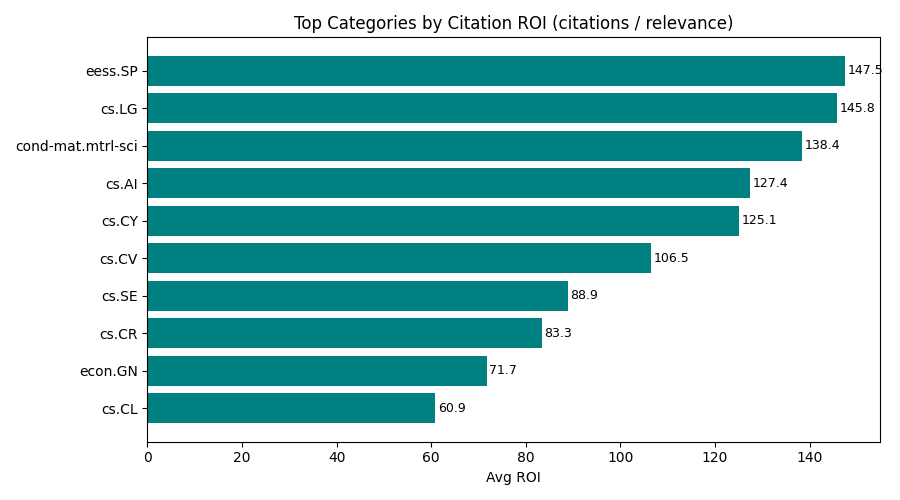

In [8]:
from src.analytics.insight_reporter import run_all_questions
from pathlib import Path
import importlib, src.analytics.insight_reporter as ir

# Override output dir to relative path for notebook
ir.ANALYTICS_DIR = Path('../data/processed/analytics')

findings = run_all_questions(df)

# Show ROI chart
from IPython.display import Image
Image('../data/processed/analytics/category_roi.png')

## Part 8 — Full Pipeline Integration Check

In [ ]:
import subprocess
result = subprocess.run(
    ['python', '../run_pipeline.py'],
    capture_output=True, text=True, cwd='..'
)
print('STDOUT:', result.stdout[-2000:] if result.stdout else '(none)')
print('STDERR:', result.stderr[-1000:] if result.stderr else '(none)')
print('Return code:', result.returncode)

## Analytics Output Files

In [9]:
from pathlib import Path
analytics_dir = Path('../data/processed/analytics')
print('Files generated:')
for f in sorted(analytics_dir.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<35} {size_kb:.1f} KB')

Files generated:
  category_analysis.csv               0.6 KB
  category_roi.png                    31.2 KB
  join_comparison.png                 14.0 KB
  pivot_category_year.csv             0.3 KB
  rolling_citations.png               35.5 KB
  yearly_trends.csv                   0.1 KB
  yearly_trends.png                   29.2 KB
  yearly_volume.png                   13.1 KB
